# Data Exploration

## Objective

The objective of this notebook is to explore the EUR/USD and GBP/USD exchange rate datasets, verify their consistency, synchronize both time series, and analyze their statistical relationship before developing any quantitative model.

The analysis focuses on understanding whether both currency pairs exhibit common movements that justify the use of dimensionality reduction techniques such as Principal Component Analysis (PCA).

The data I'm going to use are compose of the following features:

* date
* open
* high
* low
* close
* volume





In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Load data
eurusd = pd.read_csv("../data/raw/EURUSD.csv")
gbpusd = pd.read_csv("../data/raw/GBPUSD.csv")

In [9]:
# We are going to keep the features needed for the strategy
eurusd.drop(["open", "high", "low", "volume"], axis=1, inplace=True)
gbpusd.drop(["open", "high", "low", "volume"], axis=1, inplace=True)

In [10]:
# Preprocessing
# The dates in the data needs to be aligned 
eurusd["date"] = pd.to_datetime(eurusd["date"])
gbpusd["date"] = pd.to_datetime(gbpusd["date"])


eurusd_clean = eurusd[["date", "close"]].rename(
    columns={"close": "EURUSD"}
)

gbpusd_clean = gbpusd[["date", "close"]].rename(
    columns={"close": "GBPUSD"}
)


prices = pd.merge(
    eurusd_clean,
    gbpusd_clean,
    on="date",
    how="inner"
)


prices = prices.sort_values("date").set_index("date")

prices.head()

,EURUSD,GBPUSD
date,,
2010-01-26,1.40808,1.61425
2010-01-27,1.40280,1.61755
2010-01-28,1.39620,1.61415
2010-01-29,1.38605,1.59883
2010-02-01,1.39200,1.59440


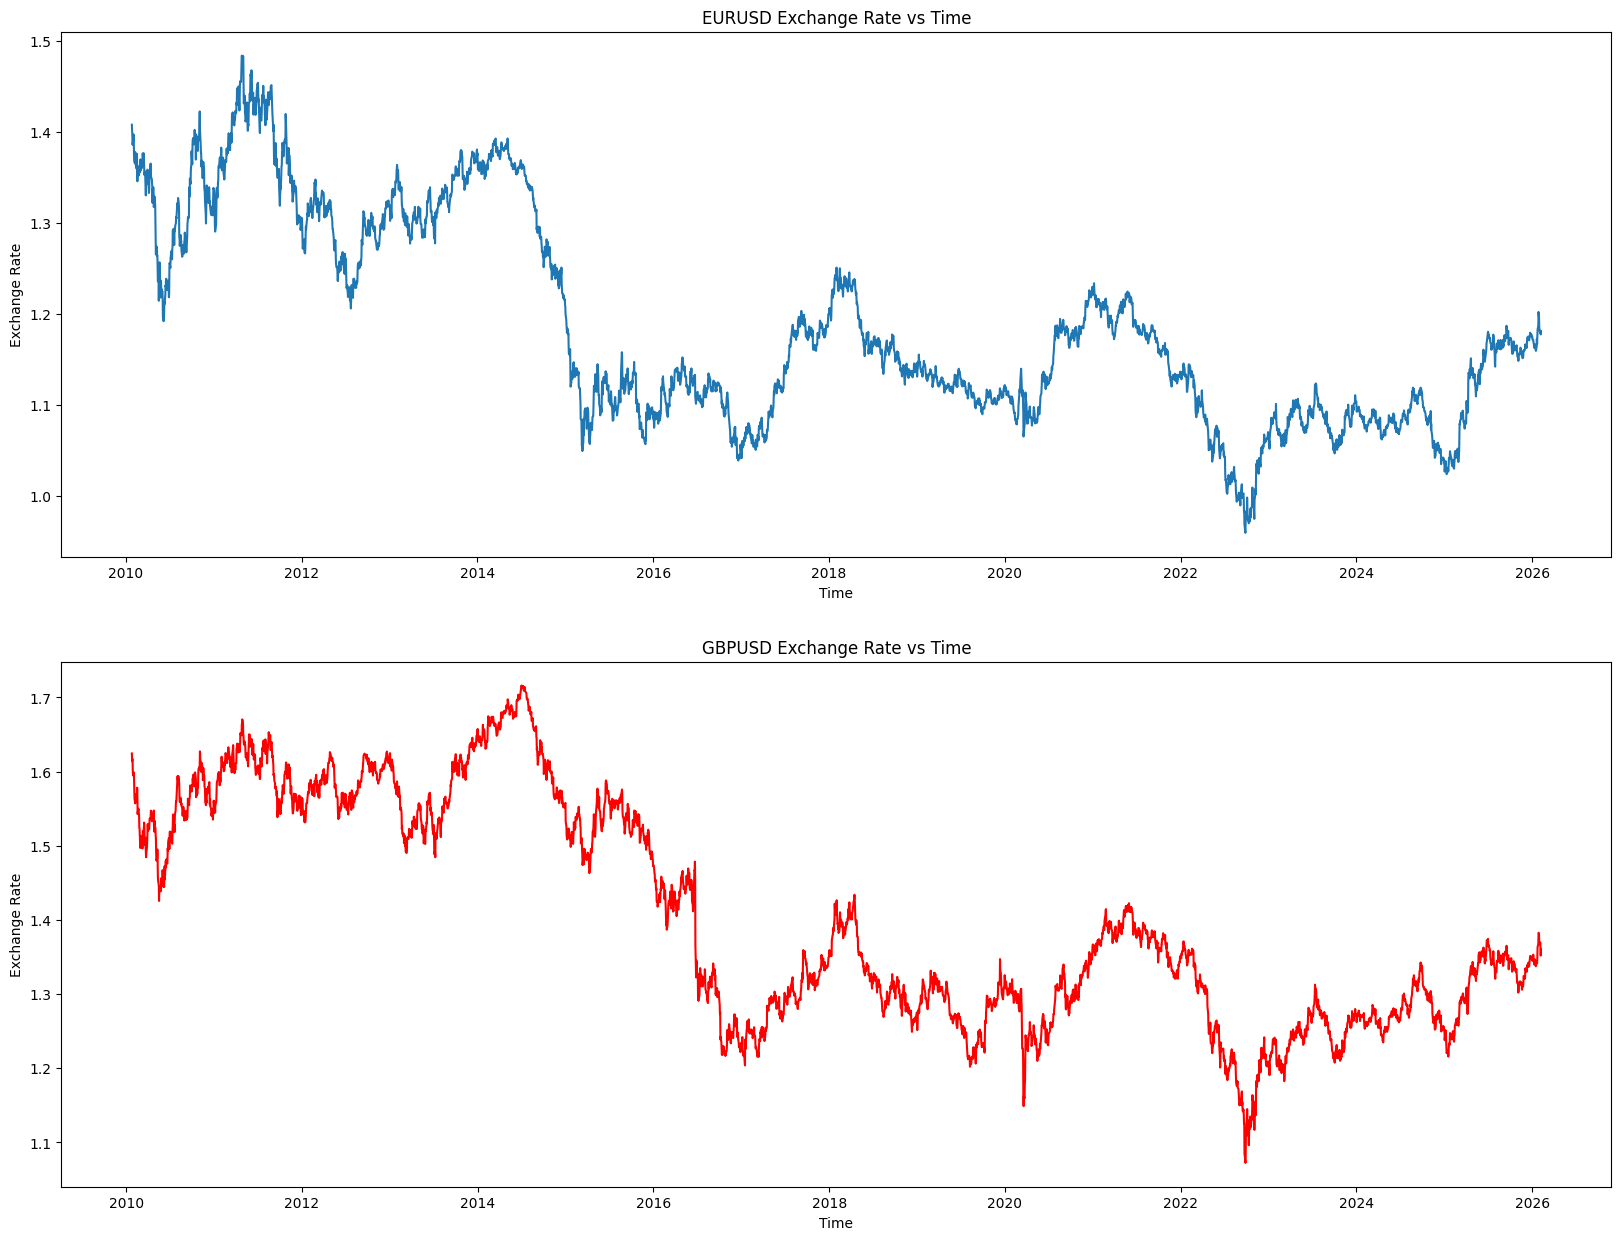

In [11]:
# Visualizing the data
fig, ax = plt.subplots(nrows=2, figsize=(20, 15))
eur_ax = ax[0]
gbp_ax = ax[1]

eur_ax.plot(eurusd["date"], eurusd["close"])
gbp_ax.plot(gbpusd["date"], gbpusd["close"], color="red")
eur_ax.set_xlabel("Time")
eur_ax.set_ylabel("Exchange Rate")
gbp_ax.set_xlabel("Time")
gbp_ax.set_ylabel("Exchange Rate")
eur_ax.set_title("EURUSD Exchange Rate vs Time")
gbp_ax.set_title("GBPUSD Exchange Rate vs Time");


From the data we can see similar movement between the EURUSD and GBPUSD exchange rate, this can indicate some strong correlation between this two pairs of currencies, it makes sense due that both pairs shares USD as the second currency, if USD takes some force relative to EURUSD, points to some appreciation of the USD that will be reflected on the exchange rate for the EUR and GBP.

> This can be use to give more validation to the idea of doing PCA to identify the factor that explain if the factor responsible for part of the USD movement is actually viable.

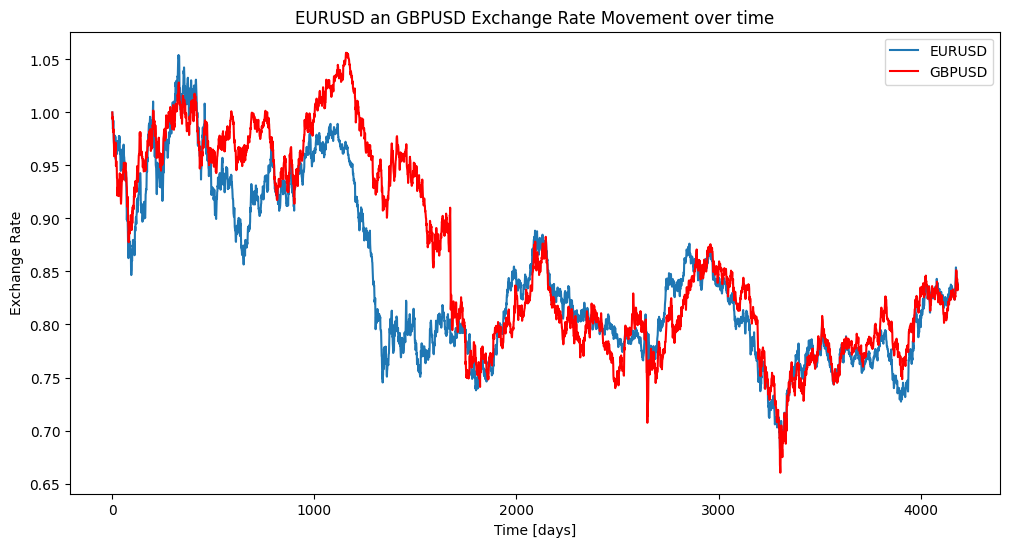

In [12]:
normalized_rates_eur = eurusd["close"] / eurusd["close"].iloc[0]
normalized_rates_gbp = gbpusd["close"] / gbpusd["close"].iloc[0]

plt.figure(figsize=(12, 6))

plt.plot(normalized_rates_eur, label="EURUSD")
plt.plot(normalized_rates_gbp, color="red", label="GBPUSD")
plt.title("EURUSD an GBPUSD Exchange Rate Movement over time")
plt.ylabel("Exchange Rate")
plt.xlabel("Time [days]")
plt.legend()
plt.show()

The graph shows the normalized rates(to be able to compare) and it looks that this exchange rates moved together, it can be thought as strong correlation, now let's see if it happens the same with the returns.

Now we can see the correlations between the returns of both currencies pairs.

<Axes: >

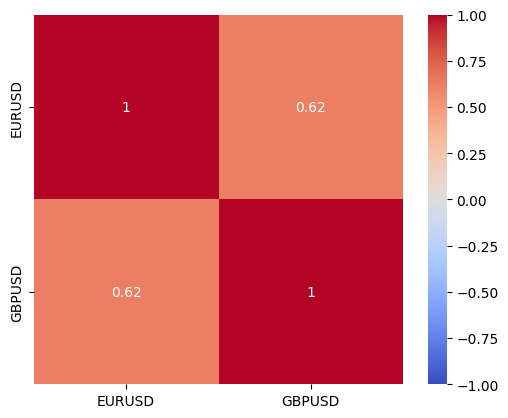

In [13]:
returns = np.log(prices / prices.shift(1)).dropna()
corr_returns_matrix = returns.corr()
sns.heatmap(corr_returns_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)

<Axes: >

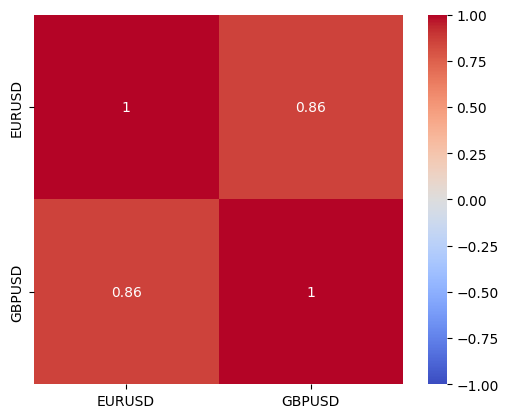

In [14]:
sns.heatmap(prices.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)

The first heatmap shows us the correlation between both returns, clearly great than 0.5, indicating that returns tend to move in the same direction, the second heatmap indicate what we have already intuit, the strong correlations between prices(see the graphics above).

## Conclusions

The exploratory analysis leads to the following observations:
 - Both exchange rates series EUR/USD and GBP/USD exhibit strong positive correlation in price levels.
 - Daily returns also show a significant positive correlation, suggesting the presence of common latent factors.
 - The existence of correlated returns motivates the application of PCA, wich will be used in the next notebook to identify the dominant sources of market variation.